In [62]:
import os
import sys
from glob import glob
import tensorflow as tf
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## 1. Configurar Directorios de Logs

Especifica los tres directorios de logs a comparar.

In [63]:
# Configurar los tres modelos a comparar
LOG_DIRS = [
    'outputs/comparison/efficientnet-b0_20260109_084143/logs',
    'outputs/comparison_02/efficientnet-b0_20260111_015704/logs',
]

# Nombres descriptivos para cada modelo
MODEL_NAMES = [
    'EfficientNet-B0',
    'EfficientNet-B0-2',
]

# Convertir a rutas absolutas
BASE_DIR = Path('..')
LOG_DIRS = [str(BASE_DIR / log_dir) for log_dir in LOG_DIRS]

# Verificar que existan
for i, log_dir in enumerate(LOG_DIRS):
    if os.path.exists(log_dir):
        print(f"✅ {MODEL_NAMES[i]}: {log_dir}")
    else:
        print(f"❌ {MODEL_NAMES[i]}: {log_dir} - NO ENCONTRADO")

✅ EfficientNet-B0: ../outputs/comparison/efficientnet-b0_20260109_084143/logs
✅ EfficientNet-B0-2: ../outputs/comparison_02/efficientnet-b0_20260111_015704/logs


## 2. Función para Leer Métricas de TensorBoard

In [64]:
def read_epoch_metrics(log_dir):
    """
    Lee los archivos de eventos de TensorBoard y extrae métricas por época
    
    Args:
        log_dir: Directorio con los logs de TensorBoard
        
    Returns:
        dict: Métricas organizadas por fase (train/validation) y época
    """
    metrics = {
        'head_training': {'train': defaultdict(dict), 'validation': defaultdict(dict)},
        'fine_tuning': {'train': defaultdict(dict), 'validation': defaultdict(dict)}
    }
    
    # Buscar archivos de eventos en todas las subcarpetas
    event_files = glob(f'{log_dir}/**/events.out.tfevents.*', recursive=True)
    
    if not event_files:
        print(f"❌ No se encontraron archivos de eventos en {log_dir}")
        return None
    
    print(f"📂 Encontrados {len(event_files)} archivos de eventos")
    
    for event_file in event_files:
        # Determinar fase y tipo (train/validation)
        phase = None
        split_type = None
        
        if 'head_training' in event_file:
            phase = 'head_training'
        elif 'fine_tuning' in event_file:
            phase = 'fine_tuning'
        else:
            continue
            
        if '/train/' in event_file:
            split_type = 'train'
        elif '/validation/' in event_file:
            split_type = 'validation'
        else:
            continue
        
        # Leer eventos
        try:
            for record in tf.data.TFRecordDataset(event_file):
                event = tf.compat.v1.Event.FromString(record.numpy())
                
                for value in event.summary.value:
                    tag = value.tag
                    
                    # Buscar métricas epoch_
                    if tag.startswith('epoch_'):
                        metric_name = tag.replace('epoch_', '')
                        step = event.step
                        
                        # Extraer valor
                        if value.HasField('simple_value'):
                            metric_value = value.simple_value
                        elif value.HasField('tensor'):
                            tensor_proto = value.tensor
                            tensor = tf.make_ndarray(tensor_proto)
                            if tensor.size == 1:
                                metric_value = float(tensor)
                            else:
                                continue
                        else:
                            continue
                        
                        # Guardar métrica por época
                        metrics[phase][split_type][step][metric_name] = metric_value
                        
        except Exception as e:
            print(f"⚠️  Error leyendo {event_file}: {e}")
            continue
    
    return metrics

## 3. Cargar Métricas de los Tres Modelos

In [65]:
# Cargar métricas para cada modelo
all_metrics = {}

for i, (log_dir, model_name) in enumerate(zip(LOG_DIRS, MODEL_NAMES)):
    print(f"\n{'='*60}")
    print(f"🔍 Leyendo {model_name}")
    print(f"{'='*60}")
    metrics = read_epoch_metrics(log_dir)
    if metrics:
        all_metrics[model_name] = metrics
        print(f"✅ Métricas cargadas exitosamente")
    else:
        print(f"❌ No se pudieron cargar métricas")

print(f"\n📊 Total de modelos cargados: {len(all_metrics)}")


🔍 Leyendo EfficientNet-B0
📂 Encontrados 4 archivos de eventos
✅ Métricas cargadas exitosamente

🔍 Leyendo EfficientNet-B0-2
📂 Encontrados 4 archivos de eventos
✅ Métricas cargadas exitosamente

📊 Total de modelos cargados: 2


## 4. Convertir a DataFrames para Análisis

In [66]:
def metrics_to_dataframe(metrics, phase='fine_tuning'):
    """
    Convierte las métricas a DataFrames separados para train y validation
    
    Args:
        metrics: Diccionario con las métricas
        phase: Fase a extraer ('head_training' o 'fine_tuning')
        
    Returns:
        tuple: (df_train, df_validation)
    """
    if phase not in metrics:
        return None, None
    
    phase_data = metrics[phase]
    
    # Convertir train a DataFrame
    train_records = []
    for epoch, epoch_metrics in sorted(phase_data['train'].items()):
        record = {'epoch': epoch}
        record.update(epoch_metrics)
        train_records.append(record)
    df_train = pd.DataFrame(train_records) if train_records else pd.DataFrame()
    
    # Convertir validation a DataFrame
    val_records = []
    for epoch, epoch_metrics in sorted(phase_data['validation'].items()):
        record = {'epoch': epoch}
        record.update(epoch_metrics)
        val_records.append(record)
    df_val = pd.DataFrame(val_records) if val_records else pd.DataFrame()
    
    return df_train, df_val

# Extraer DataFrames para cada modelo (usando fine_tuning por defecto)
dataframes = {}
for model_name, metrics in all_metrics.items():
    df_train, df_val = metrics_to_dataframe(metrics, phase='fine_tuning')
    dataframes[model_name] = {
        'train': df_train,
        'validation': df_val
    }
    print(f"\n{model_name}:")
    print(f"  Train epochs: {len(df_train)}")
    print(f"  Validation epochs: {len(df_val)}")


EfficientNet-B0:
  Train epochs: 14
  Validation epochs: 14

EfficientNet-B0-2:
  Train epochs: 20
  Validation epochs: 20


## 5. Visualización: Loss por Época

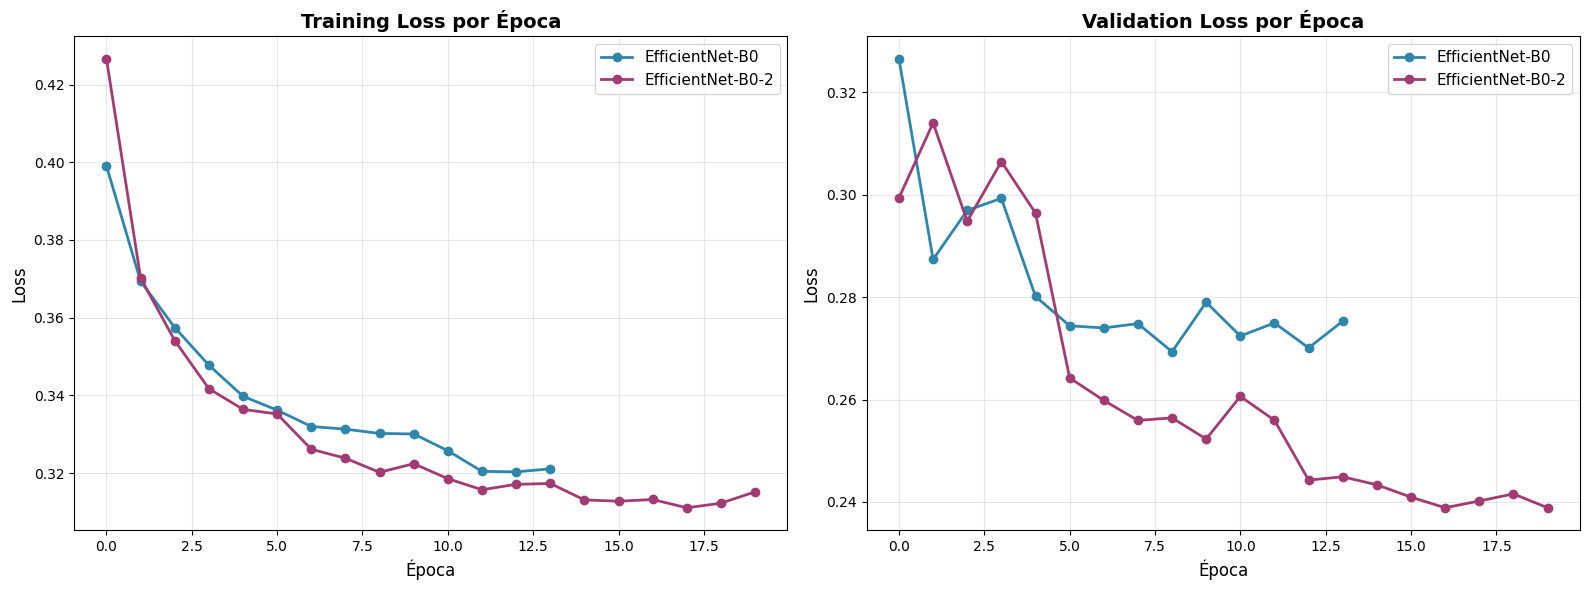

In [67]:
# Gráfico de Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2E86AB', '#A23B72', '#F18F01']

# Training Loss
for i, (model_name, dfs) in enumerate(dataframes.items()):
    df_train = dfs['train']
    if not df_train.empty and 'loss' in df_train.columns:
        ax1.plot(df_train['epoch'], df_train['loss'], 
                'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)

ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss por Época', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Validation Loss
for i, (model_name, dfs) in enumerate(dataframes.items()):
    df_val = dfs['validation']
    if not df_val.empty and 'loss' in df_val.columns:
        ax2.plot(df_val['epoch'], df_val['loss'], 
                'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)

ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Validation Loss por Época', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualización: Accuracy por Época

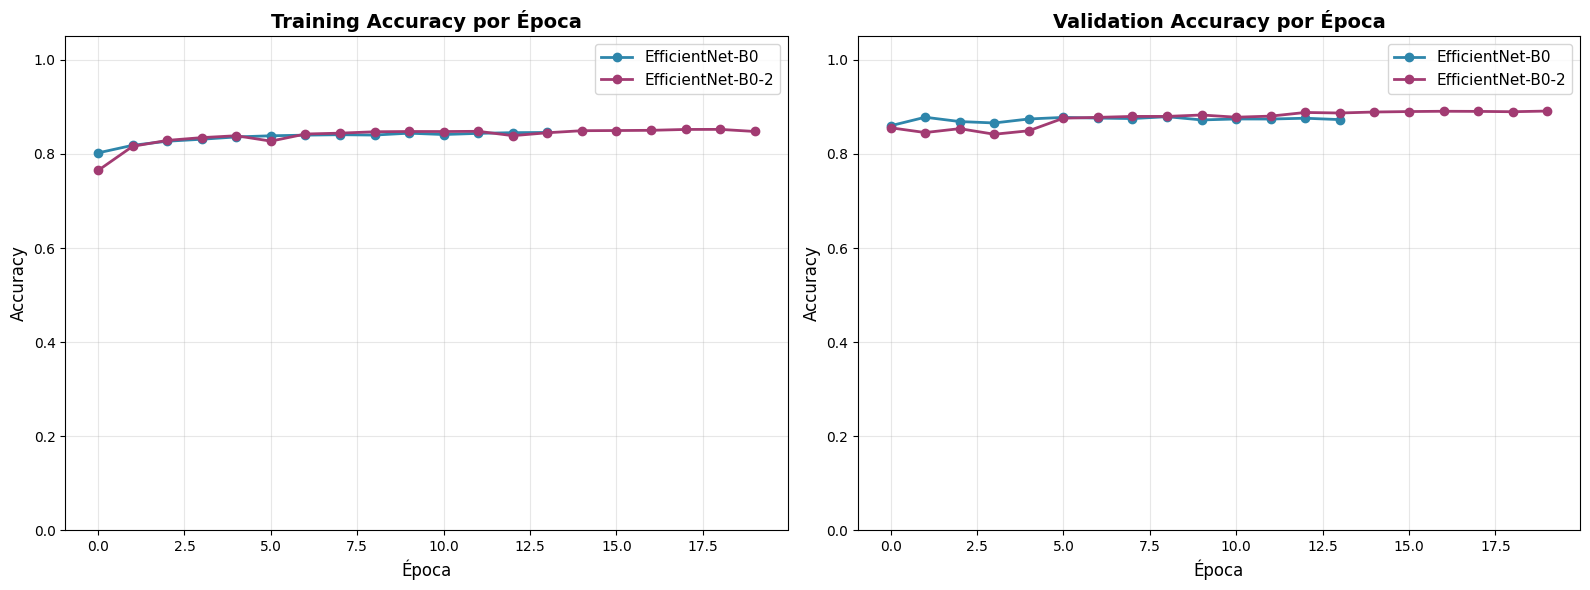

In [68]:
# Gráfico de Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Training Accuracy
for i, (model_name, dfs) in enumerate(dataframes.items()):
    df_train = dfs['train']
    if not df_train.empty and 'accuracy' in df_train.columns:
        ax1.plot(df_train['epoch'], df_train['accuracy'], 
                'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)

ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Training Accuracy por Época', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Validation Accuracy
for i, (model_name, dfs) in enumerate(dataframes.items()):
    df_val = dfs['validation']
    if not df_val.empty and 'accuracy' in df_val.columns:
        ax2.plot(df_val['epoch'], df_val['accuracy'], 
                'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)

ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy por Época', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 7. Visualización: AUC por Época

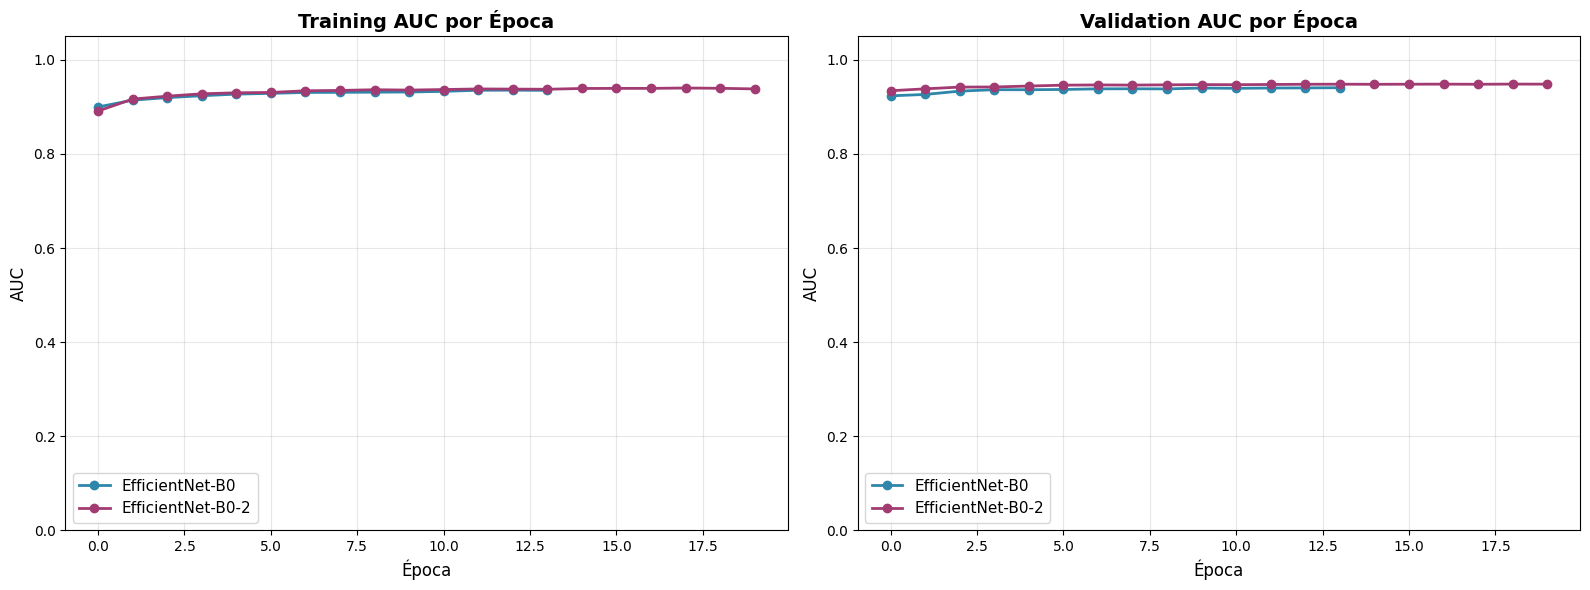

In [69]:
# Gráfico de AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Training AUC
for i, (model_name, dfs) in enumerate(dataframes.items()):
    df_train = dfs['train']
    if not df_train.empty and 'auc' in df_train.columns:
        ax1.plot(df_train['epoch'], df_train['auc'], 
                'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)

ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('AUC', fontsize=12)
ax1.set_title('Training AUC por Época', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Validation AUC
for i, (model_name, dfs) in enumerate(dataframes.items()):
    df_val = dfs['validation']
    if not df_val.empty and 'auc' in df_val.columns:
        ax2.plot(df_val['epoch'], df_val['auc'], 
                'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)

ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('AUC', fontsize=12)
ax2.set_title('Validation AUC por Época', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 8. Comparación de Última Época - Tabla Resumen

In [70]:
# Crear tabla comparativa de la última época
comparison_data = []

for model_name, dfs in dataframes.items():
    df_val = dfs['validation']
    if not df_val.empty:
        last_epoch = df_val.iloc[-1]
        comparison_data.append({
            'Model': model_name,
            'Epoch': int(last_epoch['epoch']),
            'Val Loss': last_epoch.get('loss', np.nan),
            'Val Accuracy': last_epoch.get('accuracy', np.nan),
            'Val AUC': last_epoch.get('auc', np.nan)
        })

df_comparison = pd.DataFrame(comparison_data)

print("="*70)
print("📊 COMPARACIÓN FINAL - ÚLTIMA ÉPOCA")
print("="*70)
print()

# Mostrar tabla con formato
styled_comparison = df_comparison.style.highlight_max(
    subset=['Val Accuracy', 'Val AUC'], 
    color='lightgreen'
).highlight_min(
    subset=['Val Loss'], 
    color='lightgreen'
).format({
    'Val Loss': '{:.6f}',
    'Val Accuracy': '{:.6f}',
    'Val AUC': '{:.6f}'
})

display(styled_comparison)

📊 COMPARACIÓN FINAL - ÚLTIMA ÉPOCA



,Model,Epoch,Val Loss,Val Accuracy,Val AUC
0,EfficientNet-B0,13,0.275304,0.872971,0.940794
1,EfficientNet-B0-2,19,0.238856,0.891143,0.948358


## 9. Mejor Época por Modelo

In [71]:
# Encontrar la mejor época para cada modelo (basado en validation accuracy)
best_epochs_data = []

for model_name, dfs in dataframes.items():
    df_val = dfs['validation']
    if not df_val.empty and 'accuracy' in df_val.columns:
        best_idx = df_val['accuracy'].idxmax()
        best_epoch = df_val.iloc[best_idx]
        best_epochs_data.append({
            'Model': model_name,
            'Best Epoch': int(best_epoch['epoch']),
            'Val Loss': best_epoch.get('loss', np.nan),
            'Val Accuracy': best_epoch.get('accuracy', np.nan),
            'Val AUC': best_epoch.get('auc', np.nan)
        })

df_best = pd.DataFrame(best_epochs_data)

print("="*70)
print("🏆 MEJOR ÉPOCA POR MODELO (basado en Validation Accuracy)")
print("="*70)
print()

styled_best = df_best.style.highlight_max(
    subset=['Val Accuracy', 'Val AUC'], 
    color='gold'
).highlight_min(
    subset=['Val Loss'], 
    color='lightgreen'
).format({
    'Val Loss': '{:.6f}',
    'Val Accuracy': '{:.6f}',
    'Val AUC': '{:.6f}'
})

display(styled_best)

🏆 MEJOR ÉPOCA POR MODELO (basado en Validation Accuracy)



,Model,Best Epoch,Val Loss,Val Accuracy,Val AUC
0,EfficientNet-B0,8,0.269339,0.879146,0.938265
1,EfficientNet-B0-2,19,0.238856,0.891143,0.948358


## 10. Gráfico Completo - Todas las Métricas

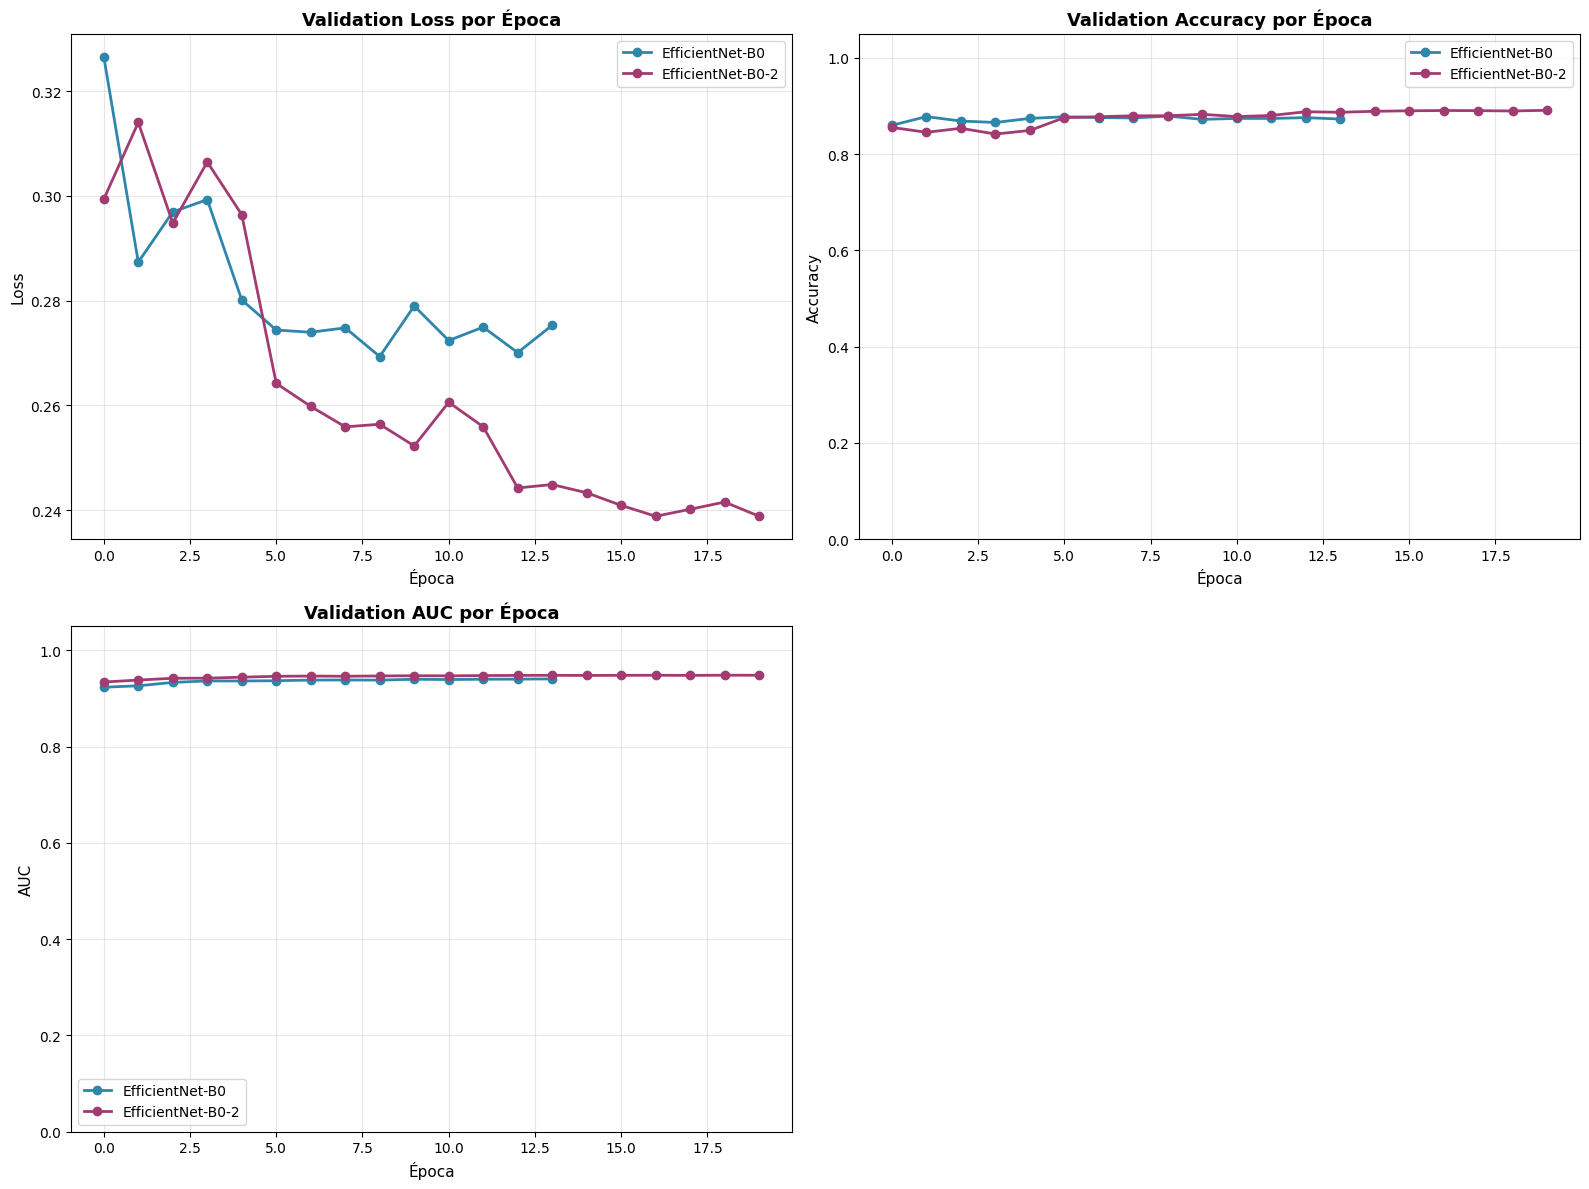

In [72]:
# Gráfico completo con todas las métricas de validation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = [
    ('loss', 'Loss', False),  # (columna, título, inverso)
    ('accuracy', 'Accuracy', True),
    ('auc', 'AUC', True),
]

for idx, (metric, title, highlight_max) in enumerate(metrics_to_plot):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    for i, (model_name, dfs) in enumerate(dataframes.items()):
        df_val = dfs['validation']
        if not df_val.empty and metric in df_val.columns:
            ax.plot(df_val['epoch'], df_val[metric], 
                   'o-', label=model_name, color=colors[i], linewidth=2, markersize=6)
    
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Validation {title} por Época', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    if metric in ['accuracy', 'auc']:
        ax.set_ylim([0, 1.05])

# Ocultar subplot vacío
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 11. Tablas Detalladas por Modelo

In [73]:
# Mostrar tablas detalladas de train y validation para cada modelo
for model_name, dfs in dataframes.items():
    print("="*70)
    print(f"📋 {model_name} - Métricas por Época")
    print("="*70)
    print()
    
    # --- TRAINING METRICS ---
    df_train = dfs['train']
    if not df_train.empty:
        print("🔵 TRAINING METRICS")
        print("-"*70)
        
        # Seleccionar columnas relevantes
        cols_to_show = ['epoch']
        for col in ['loss', 'accuracy', 'auc']:
            if col in df_train.columns:
                cols_to_show.append(col)
        
        df_display_train = df_train[cols_to_show].copy()
        df_display_train['epoch'] = df_display_train['epoch'].astype(int)
        
        styled_train = df_display_train.style.highlight_max(
            subset=[c for c in cols_to_show if c in ['accuracy', 'auc']], 
            color='lightblue'
        ).highlight_min(
            subset=[c for c in cols_to_show if c == 'loss'], 
            color='lightblue'
        ).format({
            'loss': '{:.6f}',
            'accuracy': '{:.6f}',
            'auc': '{:.6f}'
        })
        
        display(styled_train)
        print()
    
    # --- VALIDATION METRICS ---
    df_val = dfs['validation']
    if not df_val.empty:
        print("🟢 VALIDATION METRICS")
        print("-"*70)
        
        # Seleccionar columnas relevantes
        cols_to_show = ['epoch']
        for col in ['loss', 'accuracy', 'auc']:
            if col in df_val.columns:
                cols_to_show.append(col)
        
        df_display_val = df_val[cols_to_show].copy()
        df_display_val['epoch'] = df_display_val['epoch'].astype(int)
        
        styled_val = df_display_val.style.highlight_max(
            subset=[c for c in cols_to_show if c in ['accuracy', 'auc']], 
            color='lightgreen'
        ).highlight_min(
            subset=[c for c in cols_to_show if c == 'loss'], 
            color='lightgreen'
        ).format({
            'loss': '{:.6f}',
            'accuracy': '{:.6f}',
            'auc': '{:.6f}'
        })
        
        display(styled_val)
        print("\n")

📋 EfficientNet-B0 - Métricas por Época

🔵 TRAINING METRICS
----------------------------------------------------------------------


,epoch,loss,accuracy,auc
0,0,0.399071,0.802220,0.899855
1,1,0.369365,0.818339,0.914339
2,2,0.357467,0.826985,0.919684
3,3,0.347784,0.831234,0.923722
4,4,0.339781,0.836144,0.927149
5,5,0.336213,0.838600,0.928779
6,6,0.332001,0.839923,0.930670
7,7,0.331319,0.840863,0.930914
8,8,0.330217,0.840115,0.931290
9,9,0.330078,0.844108,0.931633



🟢 VALIDATION METRICS
----------------------------------------------------------------------


,epoch,loss,accuracy,auc
0,0,0.326552,0.859915,0.923503
1,1,0.287353,0.877999,0.926451
2,2,0.296950,0.868825,0.933503
3,3,0.299294,0.865826,0.936577
4,4,0.280141,0.874294,0.936475
5,5,0.274403,0.877646,0.937032
6,6,0.273975,0.876147,0.938362
7,7,0.274823,0.875176,0.938519
8,8,0.269339,0.879146,0.938265
9,9,0.278990,0.872265,0.940067




📋 EfficientNet-B0-2 - Métricas por Época

🔵 TRAINING METRICS
----------------------------------------------------------------------


,epoch,loss,accuracy,auc
0,0,0.426622,0.764880,0.891295
1,1,0.370209,0.816183,0.916595
2,2,0.354116,0.828779,0.922779
3,3,0.341735,0.834650,0.927823
4,4,0.336416,0.838685,0.929953
5,5,0.335228,0.827199,0.930684
6,6,0.326142,0.842336,0.934242
7,7,0.323837,0.844150,0.934981
8,8,0.320209,0.847118,0.936492
9,9,0.322435,0.847694,0.935749



🟢 VALIDATION METRICS
----------------------------------------------------------------------


,epoch,loss,accuracy,auc
0,0,0.299374,0.855593,0.934330
1,1,0.314025,0.845448,0.938362
2,2,0.294814,0.853740,0.942102
3,3,0.306477,0.841831,0.942315
4,4,0.296424,0.849241,0.944337
5,5,0.264222,0.875970,0.946188
6,6,0.259825,0.877735,0.946668
7,7,0.255920,0.879764,0.946346
8,8,0.256415,0.879764,0.946905
9,9,0.252278,0.882763,0.947378
